# Video Games Sales Analysis

In [18]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

In [19]:
games_data = pd.read_csv("vgsales.csv")
# games_data.head()

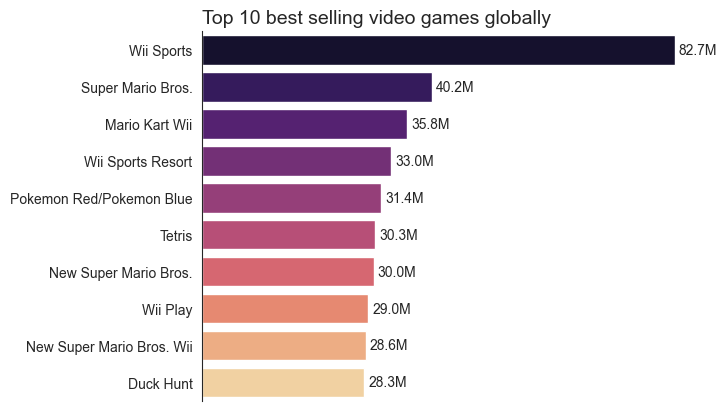

In [30]:
# Top 10 best sellers

top_games = games_data.sort_values(by="Global_Sales", ascending=False).head(10)

sns.set_style("white")
ax = sns.barplot(data=top_games, x='Global_Sales',
                y='Name', hue="Name", palette='magma',
                legend=False)

for container in ax.containers:
    ax.bar_label(container, fmt="%.1fM", padding=3)
sns.despine(bottom=True)

plt.title("Top 10 best selling video games globally", fontsize=14, loc="left")
plt.xlabel("")
plt.xticks([])
plt.ylabel("")

plt.savefig("outputs/top_10_games.png", dpi=300, bbox_inches="tight")
plt.show()

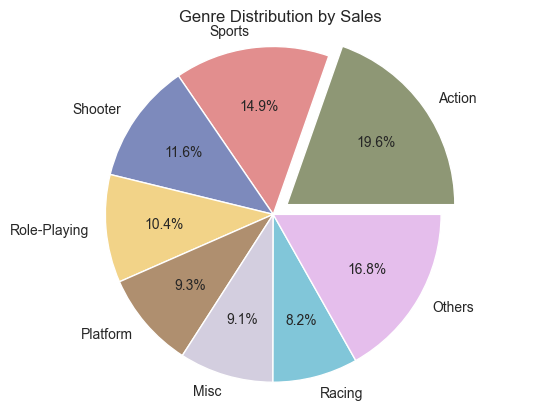

In [37]:
# Genre Distribution

genres = games_data.groupby("Genre")["Global_Sales"].sum().sort_values(ascending=False)

top_7 = genres.head(7)
others = pd.Series([genres.iloc[7:].sum()], index=["Others"])

combined_data = pd.concat([top_7, others])


colors = [
    "#8E9775", 
    "#E28E8E", 
    "#7D8ABC", 
    "#F2D388", 
    "#AF8F6F", 
    "#D3CEDF", 
    "#81C6D9", 
    "#E5BEEC"  
]

plt.pie(combined_data, 
        labels=combined_data.index,
        colors=colors,
        explode=[0.1, 0, 0, 0, 0, 0, 0, 0],
        autopct="%1.1f%%",
        pctdistance=0.65)

plt.title("Genre Distribution by Sales")
plt.axis("equal")

plt.savefig("outputs/genre_distribution.png", dpi=300, bbox_inches="tight")
plt.show()

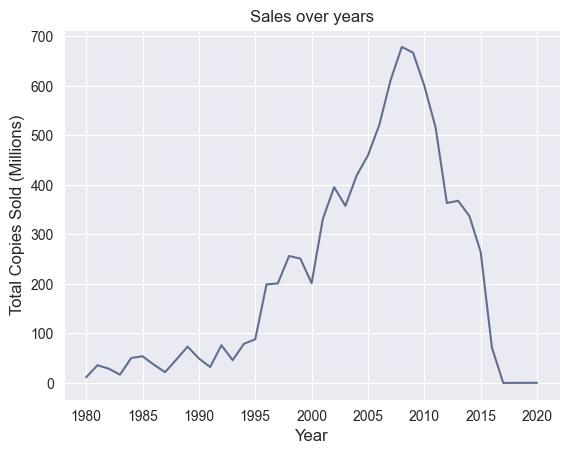

<Figure size 640x480 with 0 Axes>

In [38]:
# Sales Over Years

games_data["DateTime"] = pd.to_datetime(games_data["Year"], format="%Y")
games_data["Release_Year"] = games_data["DateTime"].dt.year

sales_by_year = games_data.groupby("Release_Year")["Global_Sales"].sum()

sns.set_style("darkgrid")
sns.lineplot(data=sales_by_year, color="#5F6F8D")

plt.title("Sales over years")
plt.xlabel("Year", fontsize=12)
plt.ylabel("Total Copies Sold (Millions)", fontsize=12)

plt.savefig("outputs/sales_over_years.png", dpi=300, bbox_inches="tight")
plt.show()


sns.despine()

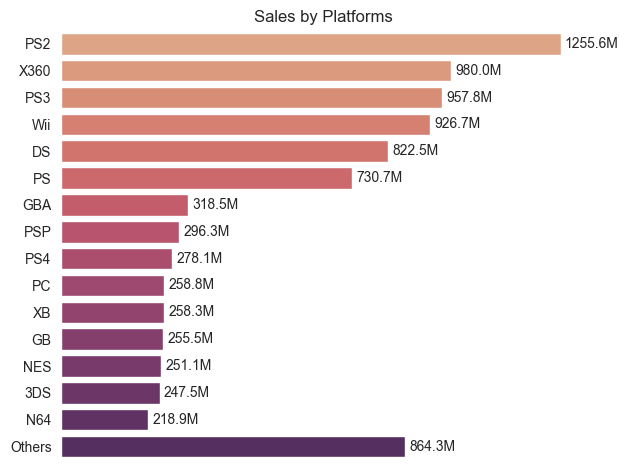

In [43]:
# Sales By Platforms

platforms = games_data.groupby("Platform")["Global_Sales"].sum().sort_values(ascending=False)
top_15 = platforms.head(15)

other_platforms = pd.Series([platforms.iloc[15:].sum()], index=["Others"])
final = pd.concat([top_15, other_platforms])

sns.set_style("white")
ax = sns.barplot(x = final.values, y = final.index, hue=final.index, palette="flare")

for container in ax.containers:
    ax.bar_label(container, fmt="%.1fM", padding=3)



sns.despine(bottom=True, left=True)

plt.title("Sales by Platforms")
plt.ylabel("")
plt.xticks([])
plt.tight_layout()

plt.savefig("outputs/sales_by_platform.png", dpi=300, bbox_inches="tight")
plt.show()